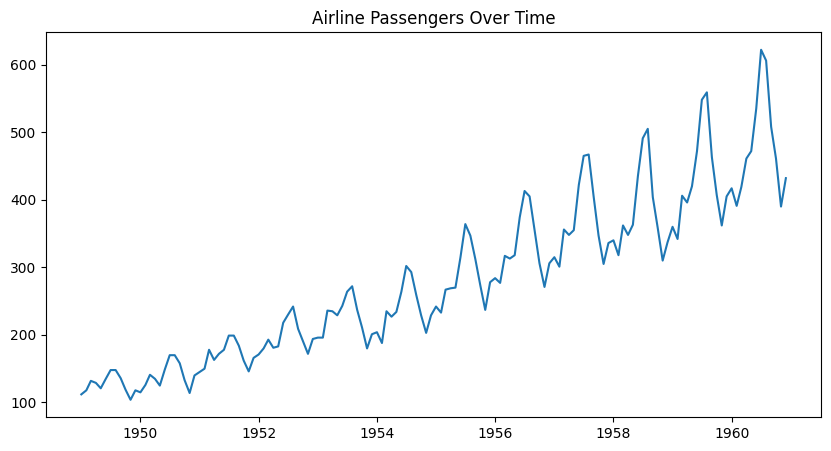

,Passengers
Month,
1949-01-01,112
1949-02-01,118
1949-03-01,132
1949-04-01,129
1949-05-01,121


In [1]:
import pandas as pd
import matplotlib.pyplot as plt

# Load dataset
url = "https://raw.githubusercontent.com/jbrownlee/Datasets/master/airline-passengers.csv"
df = pd.read_csv(url)

# Convert Month column to datetime
df['Month'] = pd.to_datetime(df['Month'])
df.set_index('Month', inplace=True)

# Plot
plt.figure(figsize=(10,5))
plt.plot(df['Passengers'])
plt.title("Airline Passengers Over Time")
plt.show()

df.head()

In [2]:
df['lag_1'] = df['Passengers'].shift(1)
df['lag_12'] = df['Passengers'].shift(12)

df.head(15)

,Passengers,lag_1,lag_12
Month,,,
1949-01-01,112,NaN,NaN
1949-02-01,118,112.0,NaN
1949-03-01,132,118.0,NaN
1949-04-01,129,132.0,NaN
1949-05-01,121,129.0,NaN
1949-06-01,135,121.0,NaN
1949-07-01,148,135.0,NaN
1949-08-01,148,148.0,NaN
1949-09-01,136,148.0,NaN


In [3]:
df[['Passengers', 'lag_12']].dropna().corr()

,Passengers,lag_12
Passengers,1.000000,0.990527
lag_12,0.990527,1.000000


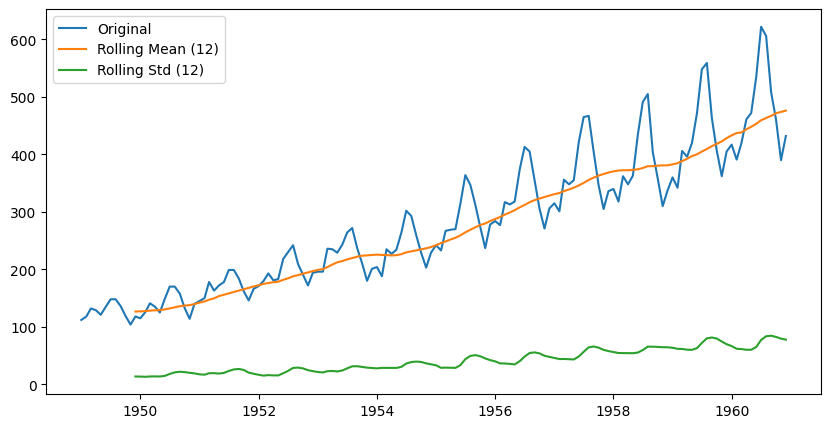

In [4]:
df['rolling_mean_12'] = df['Passengers'].rolling(window=12).mean()
df['rolling_std_12'] = df['Passengers'].rolling(window=12).std()

import matplotlib.pyplot as plt

plt.figure(figsize=(10,5))
plt.plot(df['Passengers'], label='Original')
plt.plot(df['rolling_mean_12'], label='Rolling Mean (12)')
plt.plot(df['rolling_std_12'], label='Rolling Std (12)')
plt.legend()
plt.show()

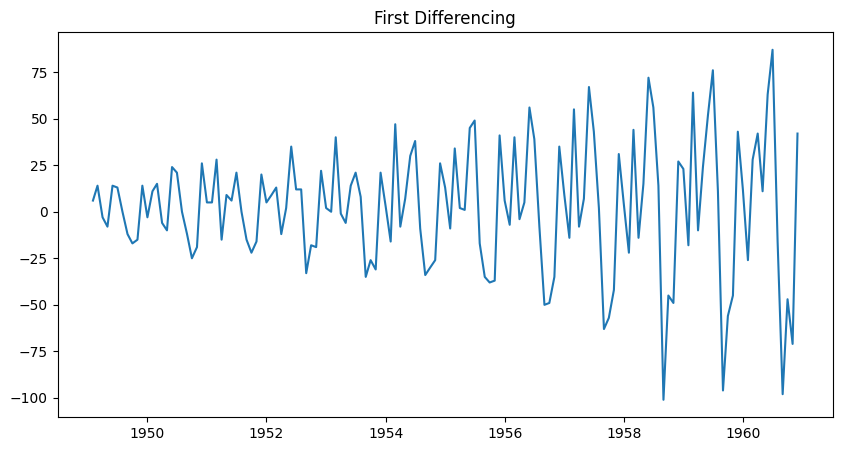

In [5]:
df['diff_1'] = df['Passengers'].diff()

plt.figure(figsize=(10,5))
plt.plot(df['diff_1'])
plt.title("First Differencing")
plt.show()

In [6]:
from statsmodels.tsa.stattools import adfuller

result = adfuller(df['diff_1'].dropna())

print("ADF Statistic:", result[0])
print("p-value:", result[1])

ADF Statistic: -2.8292668241700047
p-value: 0.05421329028382478


In [7]:
import numpy as np

df["log_passengers"] = np.log(df["Passengers"])

In [8]:
df["log_diff"] = df["log_passengers"].diff()

In [9]:
result = adfuller(df["log_diff"].dropna())

print("ADF Statistic:", result[0])
print("p-value:", result[1])

ADF Statistic: -2.717130598388114
p-value: 0.07112054815086184


In [10]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from statsmodels.tsa.stattools import adfuller

# Load dataset
from statsmodels.datasets import get_rdataset
data = get_rdataset("AirPassengers").data

# Convert to time series
ts = data["value"]

# Log Transform
log_series = np.log(ts)

# First Differencing
log_diff = log_series.diff().dropna()

# Run ADF Test
result = adfuller(log_diff)

print("ADF Statistic:", result[0])
print("p-value:", result[1])

ADF Statistic: -2.717130598388114
p-value: 0.07112054815086184


In [11]:
seasonal_diff = log_series.diff(12).dropna()

from statsmodels.tsa.stattools import adfuller

result = adfuller(seasonal_diff)

print("ADF Statistic:", result[0])
print("p-value:", result[1])

ADF Statistic: -2.7095768189885687
p-value: 0.07239567181769489


In [12]:
import numpy as np

log_series = np.log(df["Passengers"])

log_diff = log_series.diff().dropna()

seasonal_diff = log_diff.diff(12).dropna()

from statsmodels.tsa.stattools import adfuller

result = adfuller(seasonal_diff)

print("ADF Statistic:", result[0])
print("p-value:", result[1])

ADF Statistic: -4.4433249418311425
p-value: 0.00024859123113838495


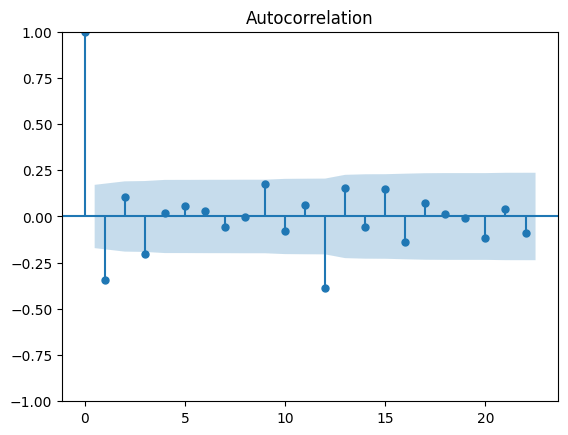

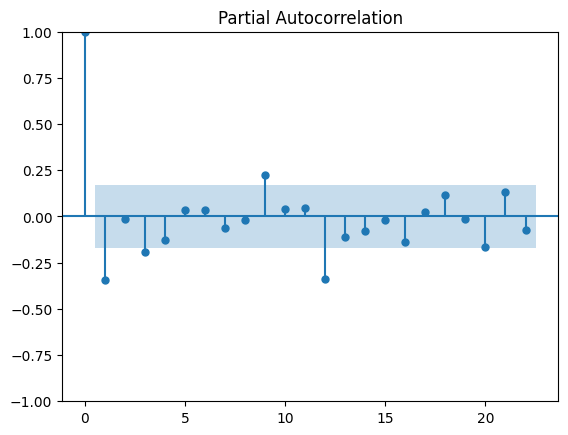

In [13]:
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
import matplotlib.pyplot as plt

plot_acf(seasonal_diff)
plot_pacf(seasonal_diff)

plt.show()

In [14]:
from statsmodels.tsa.arima.model import ARIMA

model = ARIMA(log_series, order=(1,1,0))
result = model.fit()

print(result.summary())

/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)


                               SARIMAX Results                                
Dep. Variable:             Passengers   No. Observations:                  144
Model:                 ARIMA(1, 1, 0)   Log Likelihood                 120.299
Date:                Thu, 02 Jul 2026   AIC                           -236.598
Time:                        10:21:12   BIC                           -230.672
Sample:                    01-01-1949   HQIC                          -234.190
                         - 12-01-1960                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          0.2054      0.093      2.204      0.028       0.023       0.388
sigma2         0.0109      0.002      6.050      0.000       0.007       0.014
Ljung-Box (L1) (Q):                   0.13   Jarque-

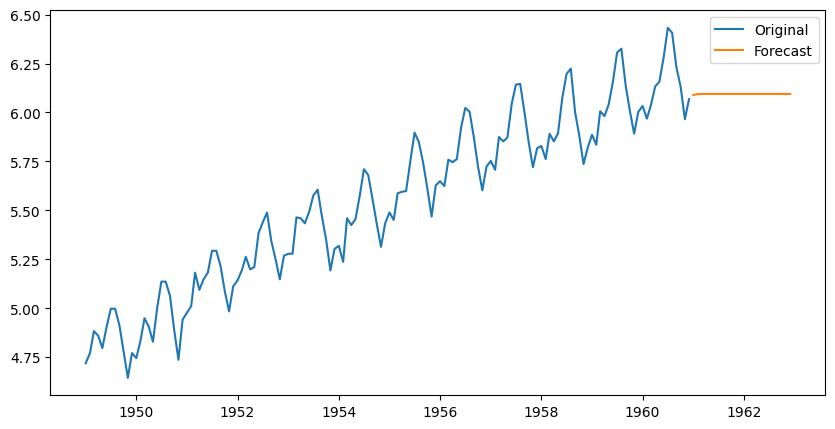

In [15]:
forecast = result.forecast(steps=24)

plt.figure(figsize=(10,5))
plt.plot(log_series, label="Original")
plt.plot(forecast, label="Forecast")
plt.legend()
plt.show()

In [16]:
from statsmodels.tsa.statespace.sarimax import SARIMAX

model = SARIMAX(
    log_series,
    order=(1,1,1),
    seasonal_order=(1,1,1,12)
)

result = model.fit()

print(result.summary())

/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)


                                     SARIMAX Results                                      
Dep. Variable:                         Passengers   No. Observations:                  144
Model:             SARIMAX(1, 1, 1)x(1, 1, 1, 12)   Log Likelihood                 245.152
Date:                            Thu, 02 Jul 2026   AIC                           -480.304
Time:                                    10:21:21   BIC                           -465.928
Sample:                                01-01-1949   HQIC                          -474.462
                                     - 12-01-1960                                         
Covariance Type:                              opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          0.1694      0.212      0.797      0.425      -0.247       0.586
ma.L1         -0.5640      0.184   

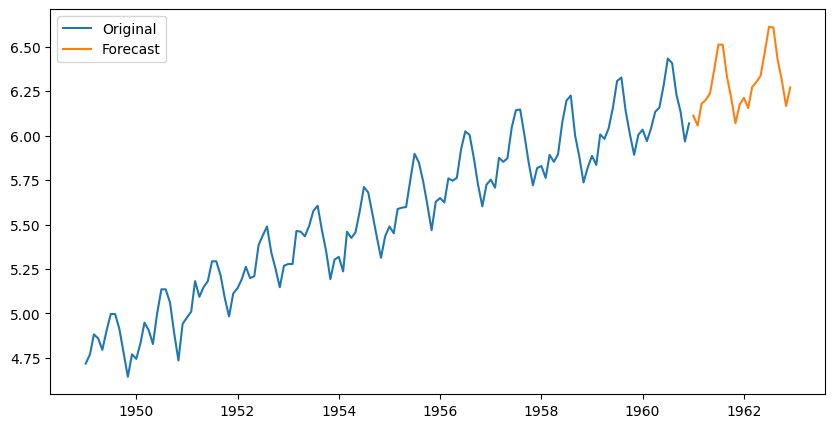

In [17]:
forecast = result.forecast(24)

plt.figure(figsize=(10,5))
plt.plot(log_series, label="Original")
plt.plot(forecast, label="Forecast")
plt.legend()
plt.show()

In [18]:
train = log_series[:'1958']
test = log_series['1959':]

In [19]:
from statsmodels.tsa.statespace.sarimax import SARIMAX

model = SARIMAX(
    train,
    order=(1,1,1),
    seasonal_order=(1,1,1,12)
)

result = model.fit()

/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


In [20]:
forecast = result.forecast(steps=len(test))

In [21]:
from sklearn.metrics import mean_squared_error
import numpy as np

rmse = np.sqrt(mean_squared_error(test, forecast))
print("RMSE:", rmse)

RMSE: 0.0881346900708467


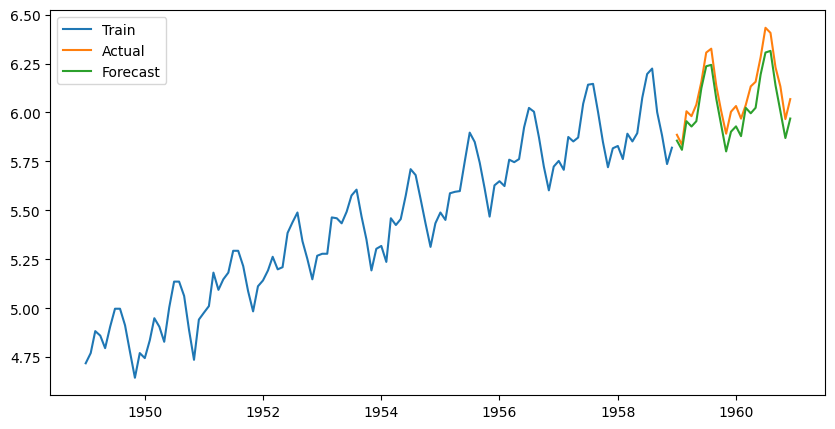

In [22]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,5))
plt.plot(train, label="Train")
plt.plot(test, label="Actual")
plt.plot(forecast, label="Forecast")
plt.legend()
plt.show()

<Figure size 1200x500 with 0 Axes>

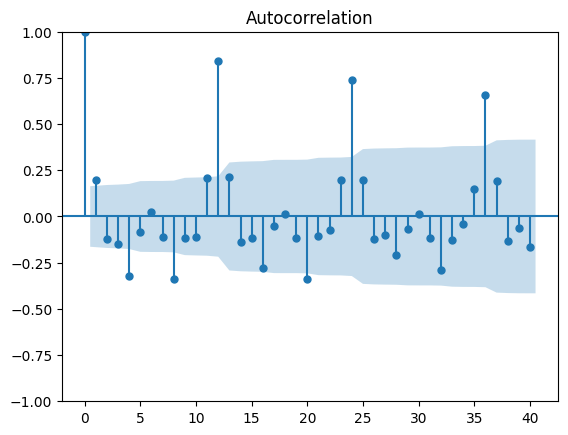

<Figure size 1200x500 with 0 Axes>

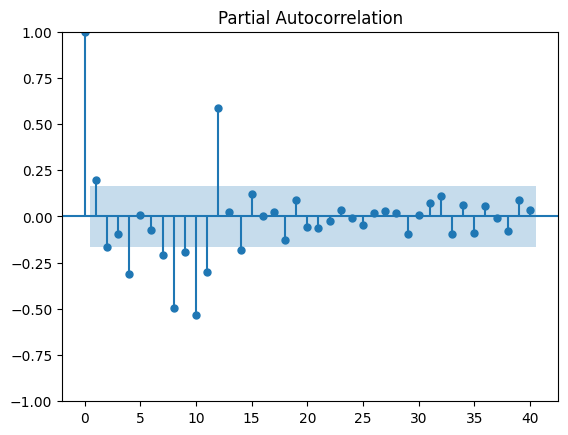

In [23]:
import matplotlib.pyplot as plt
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

plt.figure(figsize=(12,5))
plot_acf(log_diff, lags=40)
plt.show()

plt.figure(figsize=(12,5))
plot_pacf(log_diff, lags=40)
plt.show()

In [24]:
train = log_series[:'1958']
test = log_series['1959':]

print(train.shape)
print(test.shape)

(120,)
(24,)


In [25]:
from statsmodels.tsa.statespace.sarimax import SARIMAX

model = SARIMAX(
    train,
    order=(1,1,1),
    seasonal_order=(1,1,1,12)
)

results = model.fit()

print(results.summary())

/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)


                                     SARIMAX Results                                      
Dep. Variable:                         Passengers   No. Observations:                  120
Model:             SARIMAX(1, 1, 1)x(1, 1, 1, 12)   Log Likelihood                 197.717
Date:                            Thu, 02 Jul 2026   AIC                           -385.435
Time:                                    10:21:38   BIC                           -372.071
Sample:                                01-01-1949   HQIC                          -380.017
                                     - 12-01-1958                                         
Covariance Type:                              opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          0.2017      0.271      0.744      0.457      -0.330       0.733
ma.L1         -0.5344      0.245   

/usr/local/lib/python3.12/dist-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


In [26]:
forecast = results.forecast(steps=len(test))

In [27]:
forecast_actual = np.exp(forecast)
test_actual = np.exp(test)

In [28]:
from sklearn.metrics import mean_squared_error
import numpy as np

rmse = np.sqrt(mean_squared_error(test_actual, forecast_actual))

print("RMSE:", rmse)

RMSE: 39.80511131635261


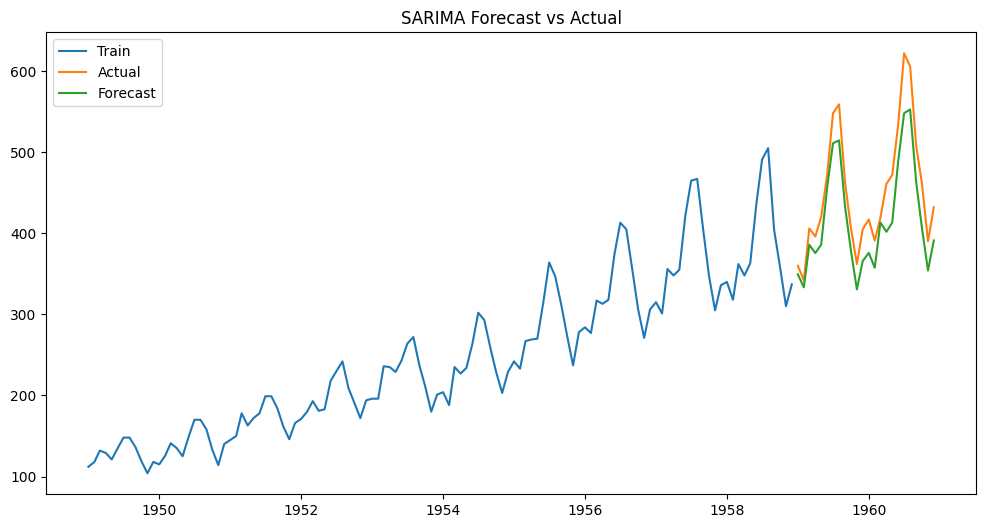

In [29]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12,6))

plt.plot(np.exp(train), label='Train')
plt.plot(test_actual, label='Actual')
plt.plot(forecast_actual, label='Forecast')

plt.legend()
plt.title("SARIMA Forecast vs Actual")
plt.show()

In [30]:
residuals = results.resid

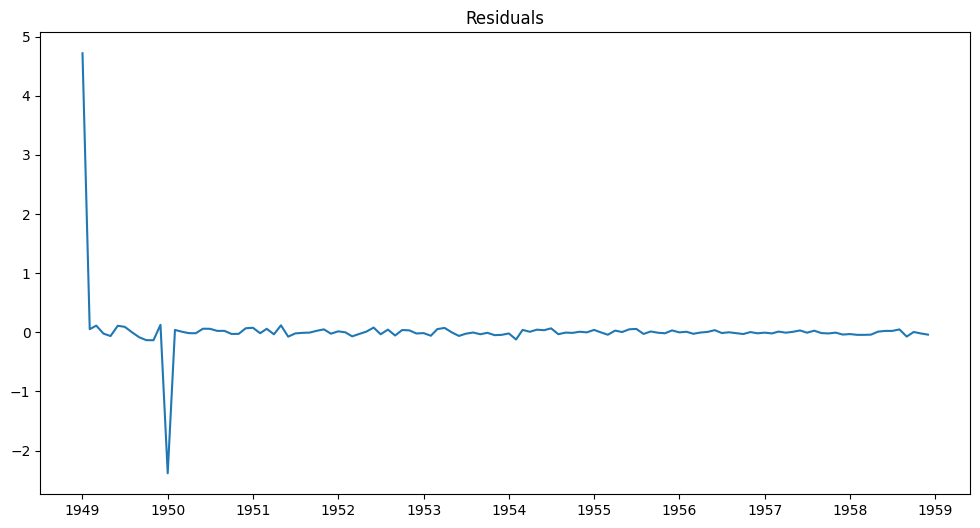

In [31]:
plt.figure(figsize=(12,6))
plt.plot(residuals)
plt.title("Residuals")
plt.show()

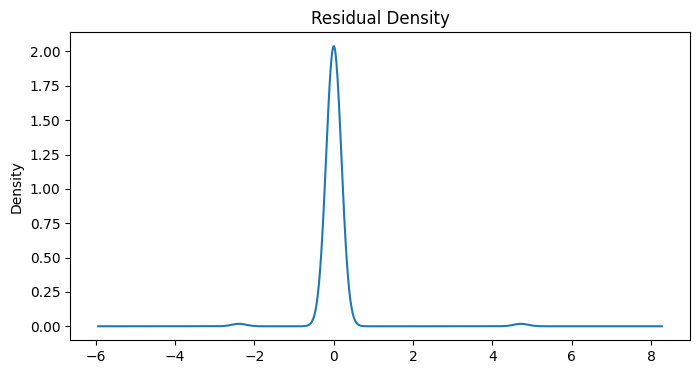

In [32]:
residuals.plot(kind='kde', figsize=(8,4))
plt.title("Residual Density")
plt.show()

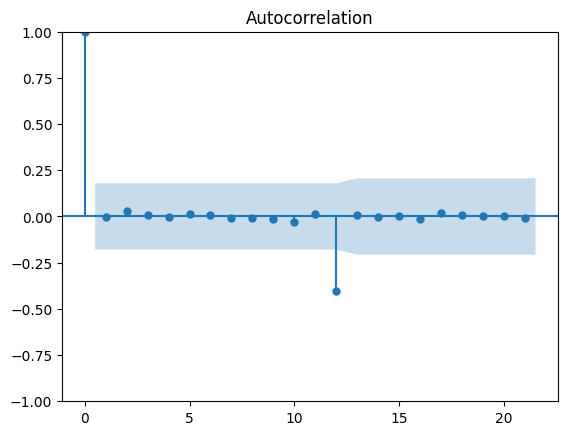

In [33]:
from statsmodels.graphics.tsaplots import plot_acf

plot_acf(residuals)
plt.show()

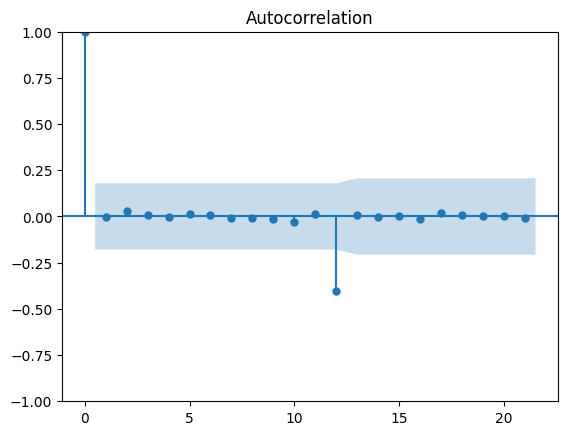

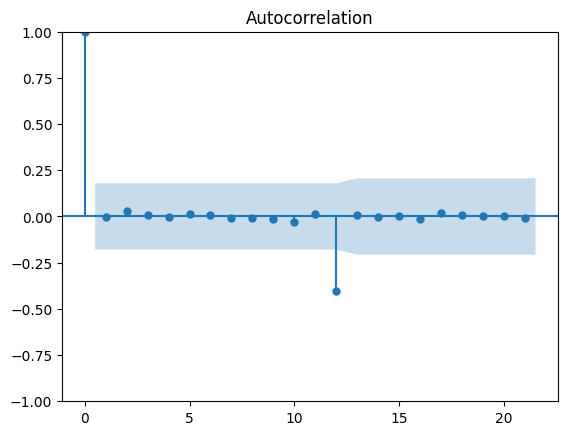

In [34]:
plot_acf(residuals)